# API + JSON → Pandas — Live Data Analysis

Many real-world data sources are accessed via REST APIs that return JSON.  
This notebook shows the full pipeline: call → parse → analyze → visualize.

**APIs used (no API key required):**
- JSONPlaceholder — fake users and posts (great for practice)
- Open-Meteo — real weather forecasts, free and open

**Topics covered:**
- `requests.get()` with params
- `response.status_code` and `response.json()`
- Flat vs nested JSON → `pd.DataFrame` vs `pd.json_normalize`
- Merge, GroupBy, charts
- Error handling with `try/except`

## 1. Setup

In [15]:
import requests
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 60)
pd.set_option("display.width", 140)
sns.set_theme(style="whitegrid")

print("Libraries loaded!")

Libraries loaded!


## 2. How a REST API Works

- An API is a standardized way to request data from another system.
- We use **GET** to fetch data.
- Most APIs return **JSON** — which Python reads as dicts and lists.

```
GET https://api.example.com/data?param=value
          ↓
    JSON response
          ↓
    pd.DataFrame
```

## 3. Example 1 — JSONPlaceholder (Users + Posts)

A public fake-data API — perfect for practicing without credentials.

Endpoints:
- `https://jsonplaceholder.typicode.com/users`
- `https://jsonplaceholder.typicode.com/posts`

### 3.1 Fetch Users

In [16]:
url_users = "https://jsonplaceholder.typicode.com/users"

resp = requests.get(url_users, timeout=20)
print("Status code:", resp.status_code)

users_raw = resp.json()
print("Type:", type(users_raw), "| Records:", len(users_raw))

Status code: 200
Type: <class 'list'> | Records: 10


### 3.2 Flat DataFrame vs json_normalize

`pd.DataFrame(data)` works for flat JSON.  
`pd.json_normalize(data)` flattens nested fields like `address.city`.

In [17]:
# Flat — nested fields appear as dicts
df_raw = pd.DataFrame(users_raw)
print("Flat columns:", list(df_raw.columns))
df_raw.head(3)

Flat columns: ['id', 'name', 'username', 'email', 'address', 'phone', 'website', 'company']


,id,name,username,email,address,phone,website,company
0,1,Leanne Graham,Bret,Sincere@april.biz,"{'street': 'Kulas Light', 'suite': 'Apt. 556',...",1-770-736-8031 x56442,hildegard.org,"{'name': 'Romaguera-Crona', 'catchPhrase': 'Mu..."
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,"{'street': 'Victor Plains', 'suite': 'Suite 87...",010-692-6593 x09125,anastasia.net,"{'name': 'Deckow-Crist', 'catchPhrase': 'Proac..."
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,"{'street': 'Douglas Extension', 'suite': 'Suit...",1-463-123-4447,ramiro.info,"{'name': 'Romaguera-Jacobson', 'catchPhrase': ..."


In [19]:
# Normalized — nested fields become dot-separated columns
users_df = pd.json_normalize(users_raw)

users_df = users_df[[
    "id", "name", "username", "email",
    "address.city", "company.name"
]].rename(columns={
    "address.city" : "city",
    "company.name" : "company"
})

users_df.head()

,id,name,username,email,city,company
0,1,Leanne Graham,Bret,Sincere@april.biz,Gwenborough,Romaguera-Crona
1,2,Ervin Howell,Antonette,Shanna@melissa.tv,Wisokyburgh,Deckow-Crist
2,3,Clementine Bauch,Samantha,Nathan@yesenia.net,McKenziehaven,Romaguera-Jacobson
3,4,Patricia Lebsack,Karianne,Julianne.OConner@kory.org,South Elvis,Robel-Corkery
4,5,Chelsey Dietrich,Kamren,Lucio_Hettinger@annie.ca,Roscoeview,Keebler LLC


### 3.3 Fetch Posts

In [20]:
url_posts = "https://jsonplaceholder.typicode.com/posts"

resp     = requests.get(url_posts, timeout=20)
print("Status code:", resp.status_code)

posts_df = pd.DataFrame(resp.json())
print("Shape:", posts_df.shape)
posts_df.head()

Status code: 200
Shape: (100, 4)


,userId,id,title,body
0,1,1,sunt aut facere repellat provident occaecati e...,quia et suscipit\nsuscipit recusandae consequu...
1,1,2,qui est esse,est rerum tempore vitae\nsequi sint nihil repr...
2,1,3,ea molestias quasi exercitationem repellat qui...,et iusto sed quo iure\nvoluptatem occaecati om...
3,1,4,eum et est occaecati,ullam et saepe reiciendis voluptatem adipisci\...
4,1,5,nesciunt quas odio,repudiandae veniam quaerat sunt sed\nalias aut...


### 3.4 Merge Posts + Users

Combine both tables on the user ID — same logic as a SQL JOIN.

In [22]:
df = posts_df.merge(users_df, left_on="userId", right_on="id", how="left")
df = df.rename(columns={"id_x": "post_id", "id_y": "user_id"})

df[["post_id", "userId", "title", "name", "city", "company"]].head()

,post_id,userId,title,name,city,company
0,1,1,sunt aut facere repellat provident occaecati e...,Leanne Graham,Gwenborough,Romaguera-Crona
1,2,1,qui est esse,Leanne Graham,Gwenborough,Romaguera-Crona
2,3,1,ea molestias quasi exercitationem repellat qui...,Leanne Graham,Gwenborough,Romaguera-Crona
3,4,1,eum et est occaecati,Leanne Graham,Gwenborough,Romaguera-Crona
4,5,1,nesciunt quas odio,Leanne Graham,Gwenborough,Romaguera-Crona


### 3.5 Mini Report — Post Count per User

In [24]:
post_summary = (
    df.groupby(["user_id", "name", "city"])["post_id"]
    .count()
    .reset_index()
    .rename(columns={"post_id": "post_count"})
    .sort_values("post_count", ascending=False)
)
post_summary

,user_id,name,city,post_count
0,1,Leanne Graham,Gwenborough,10
1,2,Ervin Howell,Wisokyburgh,10
2,3,Clementine Bauch,McKenziehaven,10
3,4,Patricia Lebsack,South Elvis,10
4,5,Chelsey Dietrich,Roscoeview,10
5,6,Mrs. Dennis Schulist,South Christy,10
6,7,Kurtis Weissnat,Howemouth,10
7,8,Nicholas Runolfsdottir V,Aliyaview,10
8,9,Glenna Reichert,Bartholomebury,10
9,10,Clementina DuBuque,Lebsackbury,10


/var/folders/_p/q81w46n1415_ly8z13fdplyr0000gn/T/ipykernel_11200/22621185.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=post_summary, x="name", y="post_count", palette="Blues_d")


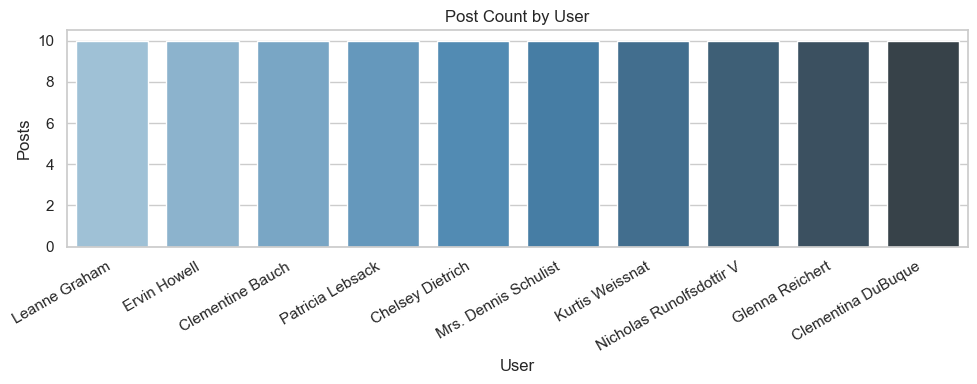

In [25]:
plt.figure(figsize=(10, 4))
sns.barplot(data=post_summary, x="name", y="post_count", palette="Blues_d")
plt.title("Post Count by User")
plt.xlabel("User")
plt.ylabel("Posts")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.show()

## 4. Example 2 — Open-Meteo (Real Weather Data)

Open-Meteo is a free, no-key-required weather API.

**Endpoint:** `https://api.open-meteo.com/v1/forecast`  
**Location:** Istanbul (lat=41.0082, lon=28.9784)

### 4.1 Make the API Call

In [26]:
url = "https://api.open-meteo.com/v1/forecast"

params = {
    "latitude"  : 41.0082,
    "longitude" : 28.9784,
    "hourly"    : "temperature_2m,precipitation,windspeed_10m",
    "timezone"  : "Europe/Istanbul"
}

resp = requests.get(url, params=params, timeout=30)
print("Status code:", resp.status_code)

weather = resp.json()
print("Top-level keys:", list(weather.keys()))

Status code: 200
Top-level keys: ['latitude', 'longitude', 'generationtime_ms', 'utc_offset_seconds', 'timezone', 'timezone_abbreviation', 'elevation', 'hourly_units', 'hourly']


### 4.2 JSON → DataFrame

In [27]:
hourly = weather["hourly"]

wdf = pd.DataFrame({
    "time"      : pd.to_datetime(hourly["time"]),
    "temp_c"    : hourly["temperature_2m"],
    "precip_mm" : hourly["precipitation"],
    "wind_kmh"  : hourly["windspeed_10m"]
})

print("Shape:", wdf.shape)
wdf.head()

Shape: (168, 4)


,time,temp_c,precip_mm,wind_kmh
0,2026-06-14 00:00:00,17.9,0.0,2.8
1,2026-06-14 01:00:00,17.8,0.0,3.3
2,2026-06-14 02:00:00,17.8,0.0,2.9
3,2026-06-14 03:00:00,17.0,0.0,1.9
4,2026-06-14 04:00:00,16.9,0.0,1.9


### 4.3 Temperature Trend — Next 48 Hours

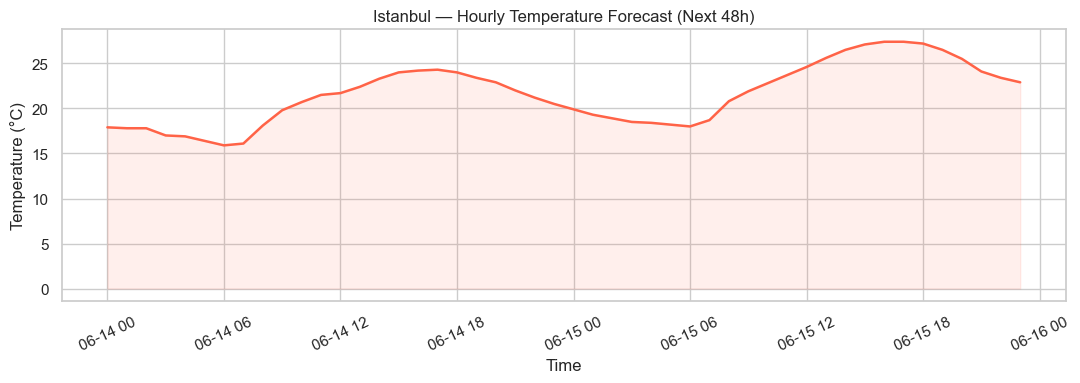

In [28]:
next_48 = wdf.head(48)

plt.figure(figsize=(11, 4))
sns.lineplot(data=next_48, x="time", y="temp_c", color="tomato", linewidth=1.8)
plt.fill_between(next_48["time"], next_48["temp_c"], alpha=0.1, color="tomato")
plt.title("Istanbul — Hourly Temperature Forecast (Next 48h)")
plt.xlabel("Time")
plt.ylabel("Temperature (°C)")
plt.xticks(rotation=25)
plt.tight_layout()
plt.show()

### 4.4 Daily Summary — Max Temp and Total Precipitation

In [30]:
wdf["date"] = wdf["time"].dt.date

daily = wdf.groupby("date").agg(
    max_temp    = ("temp_c",    "max"),
    min_temp    = ("temp_c",    "min"),
    total_rain  = ("precip_mm", "sum"),
    avg_wind    = ("wind_kmh",  "mean")
).reset_index()

daily

,date,max_temp,min_temp,total_rain,avg_wind
0,2026-06-14,24.3,15.9,0.0,5.737500
1,2026-06-15,27.4,18.0,0.0,5.979167
2,2026-06-16,30.3,20.4,0.0,8.629167
3,2026-06-17,26.7,20.9,0.0,14.537500
4,2026-06-18,26.5,20.5,0.3,16.020833
5,2026-06-19,26.5,20.4,0.0,14.762500
6,2026-06-20,28.9,18.7,0.0,8.679167


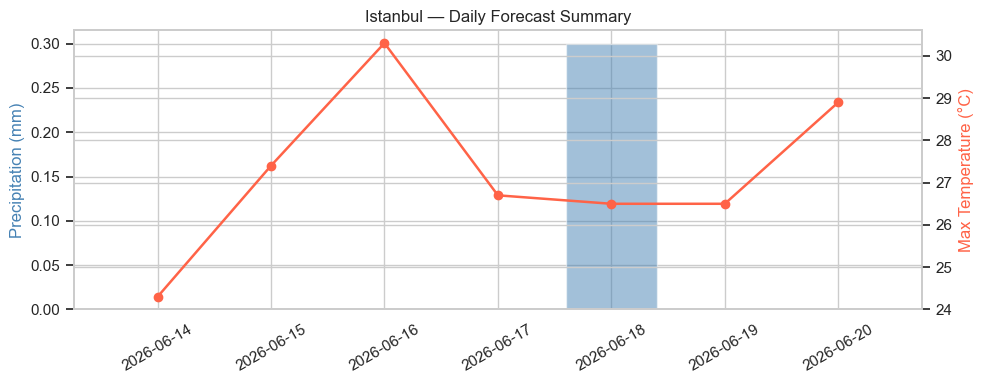

In [31]:
fig, ax1 = plt.subplots(figsize=(10, 4))

ax1.bar(daily["date"].astype(str), daily["total_rain"],
        color="steelblue", alpha=0.5, label="Precipitation (mm)")
ax1.set_ylabel("Precipitation (mm)", color="steelblue")
ax1.tick_params(axis="x", rotation=30)

ax2 = ax1.twinx()
ax2.plot(daily["date"].astype(str), daily["max_temp"],
         color="tomato", marker="o", linewidth=1.8, label="Max Temp (°C)")
ax2.set_ylabel("Max Temperature (°C)", color="tomato")

plt.title("Istanbul — Daily Forecast Summary")
plt.tight_layout()
plt.show()

## 5. Error Handling — Safe API Wrapper

Network calls can fail. Always wrap them in `try/except`.

In [32]:
def fetch_json(url, params=None, timeout=20):
    """
    Makes a GET request and returns parsed JSON.
    Returns None if the request fails.
    """
    try:
        r = requests.get(url, params=params, timeout=timeout)
        r.raise_for_status()  # raises for 4xx / 5xx status codes
        return r.json()
    except requests.exceptions.RequestException as e:
        print("Request failed:", e)
        return None


data = fetch_json("https://jsonplaceholder.typicode.com/todos")
print("Success :", data is not None)
print("Records :", len(data) if data else 0)


Success : True
Records : 200


## Summary

| Step | Tool |
|---|---|
| Make an API call | `requests.get(url, params=params)` |
| Check response | `response.status_code` |
| Parse JSON | `response.json()` |
| Flat JSON → DataFrame | `pd.DataFrame(data)` |
| Nested JSON → DataFrame | `pd.json_normalize(data)` |
| Enrich with join | `df.merge(...)` |
| Aggregate | `groupby().agg()` |
| Error handling | `try / except RequestException` |

### 💡 Data Engineering Insights:
* **Data Extraction:** Successfully connected to an external REST API to fetch and retrieve live data payloads in JSON format.
* **Data Normalization:** Flattened complex, nested JSON structures and transformed them into clean Pandas DataFrames to accelerate downstream data analytics and prepare the dataset for potential machine learning workflows.